# Створення нейронної мережі

У цьому завданні ми створимо повнозв'язну нейронну мережу, використовуючи при цьому низькорівневі механізми tensorflow.

Архітектура нейромережі представлена на наступному малюнку. Як бачиш, у ній є один вхідний шар, два приховані, а також вихідний шар. В якості активаційної функції у прихованих шарах буде використовуватись сигмоїда. На вихідному шарі ми використовуємо softmax.

Частина коду зі створення мережі вже написана, тобі потрібно заповнити пропуски у вказаних місцях.

## Архітектура нейронної мережі

<img src="http://cs231n.github.io/assets/nn1/neural_net2.jpeg" alt="nn" style="width: 400px;"/>


## Про датасет MNIST

Дану нейромережу ми будемо вивчати на датасеті MNIST. Цей датасет являє собою велику кількість зображень рукописних цифр розміром $28 \times 28$ пікселів. Кожен піксель приймає значення від 0 до 255.

Як і раніше, датасет буде розділений на навчальну та тестову вибірки. При цьому ми виконаємо нормалізацію всіх зображень, щоб значення пікселів знаходилось у проміжку від 0 до 1, розділивши яскравість кожного пікселя на 255.

Окрім того, архітектура нейронної мережі очікує на вхід вектор. У нашому ж випадку кожен об'єкт вибірки являє собою матрицю. Що ж робити? У цьому завданні ми "розтягнемо" матрицю $28 \times 28$, отримавши при цьому вектор, що складається з 784 елементів.

![MNIST Dataset](https://www.researchgate.net/profile/Steven-Young-5/publication/306056875/figure/fig1/AS:393921575309346@1470929630835/Example-images-from-the-MNIST-dataset.png)

Більше інформації про датасет можна знайти [тут](http://yann.lecun.com/exdb/mnist/).

In [27]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import keras as K
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

In [28]:
num_classes = 10 # загальна кількість класів, у нашому випадку це цифри від 0 до 9
num_features = 784 # кількість атрибутів вхідного вектора 28 * 28 = 784

learning_rate = 0.001 # швидкість навчання нейронної мережі
training_steps = 3000 # максимальне число епох
batch_size = 256 # перераховувати ваги мережі ми будемо не на всій вибірці, а на її випадковій підмножині з batch_size елементів
display_step = 100 # кожні 100 ітерацій ми будемо показувати поточне значення функції втрат і точності

n_hidden_1 = 128 # кількість нейронів 1-го шару
n_hidden_2 = 256 # кількість нейронів 2-го шару

In [29]:
# from tensorflow.keras.datasets import mnist
from keras.datasets import mnist

# Завантажуємо датасет
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Перетворюємо цілочисельні пікселі на тип float32
x_train, x_test = np.array(x_train, np.float32), np.array(x_test, np.float32)

# Перетворюємо матриці розміром 28x28 пікселів у вектор з 784 елементів
x_train, x_test = x_train.reshape([-1, num_features]), x_test.reshape([-1, num_features])

# Нормалізуємо значення пікселів
x_train, x_test = x_train / 255., x_test / 255.

# Перемішаємо тренувальні дані
train_data = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_data = train_data.repeat().shuffle(5000).batch(batch_size).prefetch(1)

In [30]:
# Створимо нейронну мережу

class DenseLayer(tf.Module):
    def __init__(self, in_features, out_features, name=None):
        super().__init__(name=name)
        self.w = tf.Variable(
            tf.random.normal([in_features, out_features]), name="w"
        )
        self.b = tf.Variable(tf.zeros([out_features]), name="b")

    def __call__(self, x, activation=0):
        y = tf.matmul(x, self.w) + self.b
        if activation != 0:
            return tf.nn.softmax(y)
        else:
            return tf.nn.sigmoid(y)

class NN(tf.Module):
  def __init__(self, name=None):
    super().__init__(name=name)
    # Перший шар, який складається з 128 нейронів
    self.layer_1 = DenseLayer(num_features, n_hidden_1, name="layer_1")
    # Другий шар, який складається з 256 нейронів
    self.layer_2 = DenseLayer(n_hidden_1, n_hidden_2, name="layer_2")
    # Вихідний шар
    self.out_layer = DenseLayer(n_hidden_2, num_classes, name="out_layer")


  def __call__(self, x):
    # Передача даних через перші два шари та вихідний шар з функцією активації softmax
    x = self.layer_1(x)
    x = self.layer_2(x)
    x = self.out_layer(x, activation=1)


    return x

In [31]:
# В якості функції помилки в даному випадку зручно взяти крос-ентропію
def cross_entropy(y_pred, y_true):
    # Закодувати label в one hot vector
    y_true = tf.one_hot(y_true, depth=num_classes)

    # Значення передбачення, щоб уникнути помилки log(0).
    y_pred = tf.clip_by_value(y_pred, 1e-9, 1.)

    # Обчислення крос-ентропії
    return tf.reduce_mean(-tf.reduce_sum(y_true * tf.math.log(y_pred)))

# Як метрику якості використовуємо точність
def accuracy(y_pred, y_true):
    correct_prediction = tf.equal(tf.argmax(y_pred, axis=1, output_type=tf.int32), tf.cast(y_true, tf.int32))
    return tf.reduce_mean(tf.cast(correct_prediction, tf.float32))

In [32]:
# Створимо екземпляр нейронної мережі
neural_net = NN(name="mnist")

# Функція навчання нейромережі
def train(neural_net, input_x, output_y):
  # Для налаштування вагів мережі будемо використовувати стохастичний градієнтний спуск
  optimizer = tf.optimizers.SGD(learning_rate)

  # Активація автоматичного диференціювання
  with tf.GradientTape() as g:
    pred = neural_net(input_x)
    loss = cross_entropy(pred, output_y)

    # Отримаємо список оптимізованих параметрів
    trainable_variables = neural_net.trainable_variables
    # Обчислимо за ними значення градієнта
    gradients = g.gradient(loss, trainable_variables)

    # Модифікуємо параметри
    optimizer.apply_gradients(zip(gradients, trainable_variables))

In [33]:
# Тренування мережі

loss_history = []  # кожні display_step кроків зберігай в цьому списку поточну помилку нейромережі
accuracy_history = [] # кожні display_step кроків зберігай в цьому списку поточну точність нейромережі
steps_history = []
# У цьому циклі ми будемо проводити навчання нейронної мережі
# із тренувального датасета train_data вилучи випадкову підмножину, на якій
# відбудеться тренування. Використовуй метод take, доступний для тренувального датасета.
for step, (batch_x, batch_y) in enumerate(train_data.take(training_steps), 1):
    # Оновлюємо ваги нейронної мережі
    train(neural_net, batch_x, batch_y)

    if step % display_step == 0:
        pred = neural_net(batch_x)
        loss = cross_entropy(pred, batch_y)
        acc = accuracy(pred, batch_y)

        steps_history.append(step)
        loss_history.append(loss.numpy())
        accuracy_history.append(acc.numpy())

        print(f"Крок: {step}, втрата: {loss.numpy():.4f}, точність: {acc.numpy():.4f}")

Крок: 100, втрата: 290.0346, точність: 0.6992
Крок: 200, втрата: 219.0316, точність: 0.7734
Крок: 300, втрата: 153.4314, точність: 0.8008
Крок: 400, втрата: 151.4166, точність: 0.8438
Крок: 500, втрата: 170.9836, точність: 0.8359
Крок: 600, втрата: 140.9980, точність: 0.8633
Крок: 700, втрата: 136.1972, точність: 0.8398
Крок: 800, втрата: 126.3624, точність: 0.8594
Крок: 900, втрата: 107.5681, точність: 0.8555
Крок: 1000, втрата: 112.9619, точність: 0.8672
Крок: 1100, втрата: 96.8547, точність: 0.8984
Крок: 1200, втрата: 114.5730, точність: 0.8945
Крок: 1300, втрата: 90.5953, точність: 0.8984
Крок: 1400, втрата: 87.7263, точність: 0.9023
Крок: 1500, втрата: 91.0791, точність: 0.8984
Крок: 1600, втрата: 62.5115, точність: 0.9258
Крок: 1700, втрата: 70.3388, точність: 0.9062
Крок: 1800, втрата: 85.8182, точність: 0.9102
Крок: 1900, втрата: 78.6891, точність: 0.8984
Крок: 2000, втрата: 78.5878, точність: 0.8984
Крок: 2100, втрата: 57.8070, точність: 0.9375
Крок: 2200, втрата: 95.9165, точ

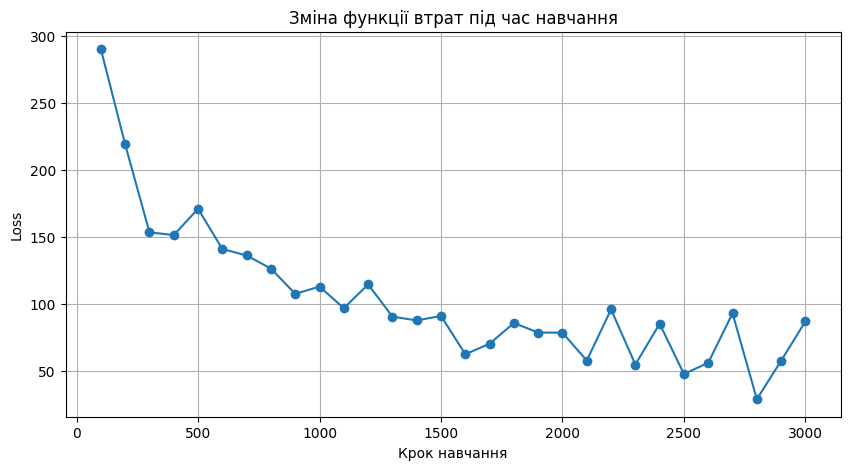

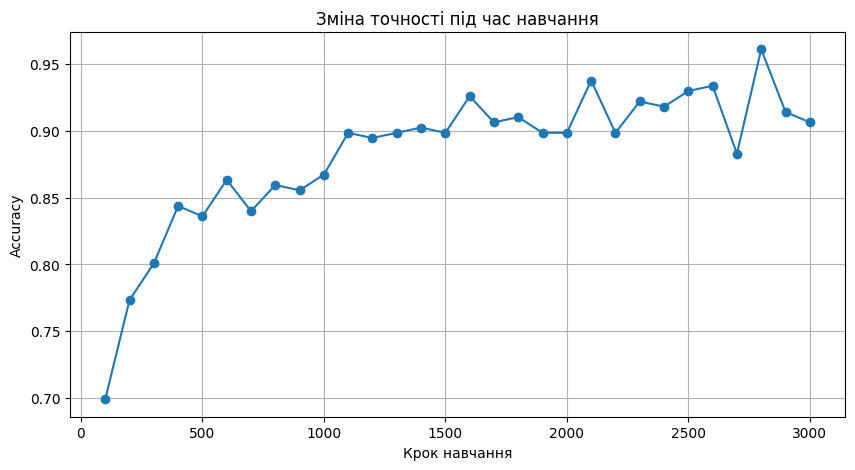

In [34]:
# Виведіть графіки залежності зміни точності і втрат від кроку
# Якщо все зроблено правильно, то точність повинна зростати, а втрати зменшуватись

import matplotlib.pyplot as plt

# Виведіть графік функції втрат
plt.figure(figsize=(10, 5))
plt.plot(steps_history, loss_history, marker='o')
plt.title('Зміна функції втрат під час навчання')
plt.xlabel('Крок навчання')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

# Виведіть графік точності
plt.figure(figsize=(10, 5))
plt.plot(steps_history, accuracy_history, marker='o')
plt.title('Зміна точності під час навчання')
plt.xlabel('Крок навчання')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

Втрати мережі на тестових даних: 3286.8362
Точність мережі на тестових даних: 0.9037


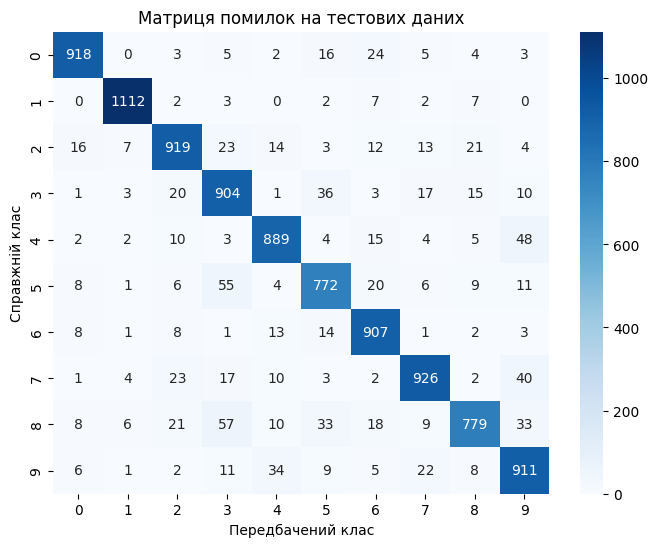

              precision    recall  f1-score   support

           0     0.9483    0.9367    0.9425       980
           1     0.9780    0.9797    0.9789      1135
           2     0.9063    0.8905    0.8983      1032
           3     0.8378    0.8950    0.8655      1010
           4     0.9099    0.9053    0.9076       982
           5     0.8655    0.8655    0.8655       892
           6     0.8954    0.9468    0.9203       958
           7     0.9214    0.9008    0.9110      1028
           8     0.9143    0.7998    0.8532       974
           9     0.8570    0.9029    0.8793      1009

    accuracy                         0.9037     10000
   macro avg     0.9034    0.9023    0.9022     10000
weighted avg     0.9047    0.9037    0.9036     10000



In [35]:
# Обчисліть точність навченої нейромережі
# Тестування моделі на тестових даних

test_pred = neural_net(x_test)
test_loss = cross_entropy(test_pred, y_test)
test_accuracy = accuracy(test_pred, y_test)
y_pred_classes = tf.argmax(test_pred, axis=1).numpy()

print(f"Втрати мережі на тестових даних: {test_loss.numpy():.4f}")
print(f"Точність мережі на тестових даних: {test_accuracy.numpy():.4f}")

# Матриця помилок
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Матриця помилок на тестових даних')
plt.xlabel('Передбачений клас')
plt.ylabel('Справжній клас')
plt.show()

# Метрики якості для кожного класу
print(classification_report(y_test, y_pred_classes, digits=4))


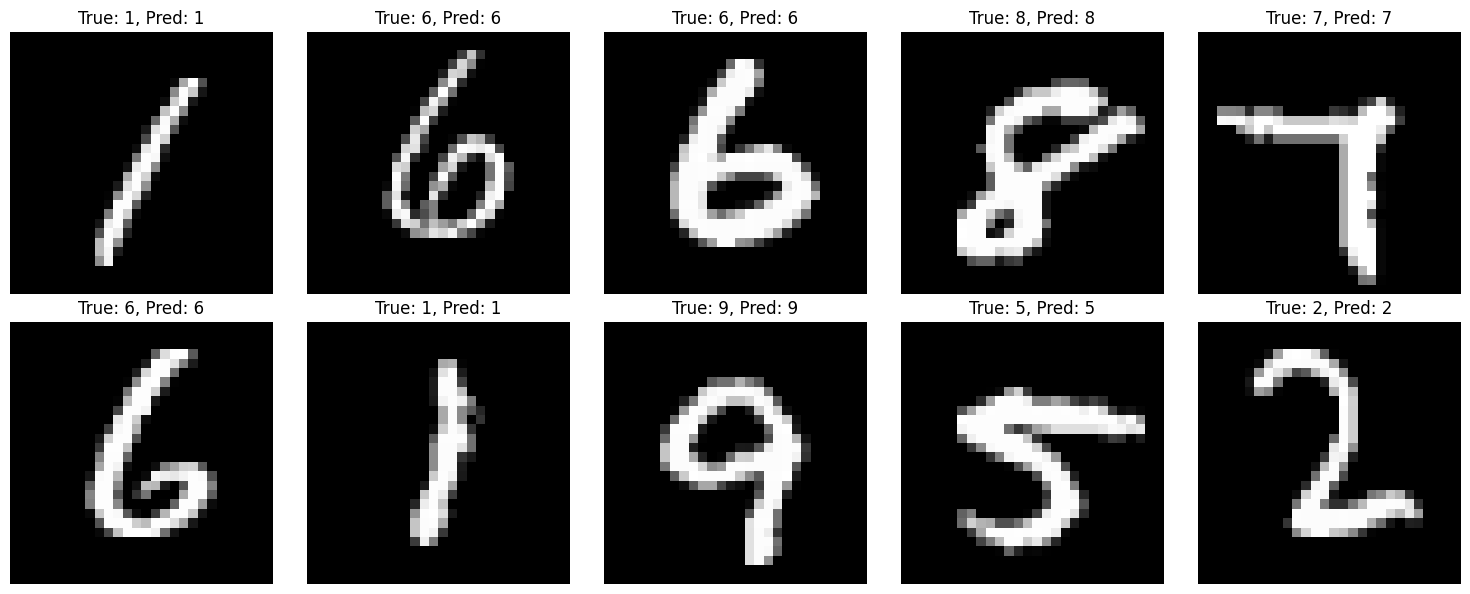

Кількість помилок на 10 випадкових тестових зображеннях: 0
Частка помилок на цій малій вибірці: 0.00%


In [37]:
# Протестуйте навчену нейромережу на 10 зображеннях. З тестової вибірки візьміть 5
# випадкових зображень і передайте їх у нейронну мережу.
# Виведіть зображення та випишіть  поруч відповідь нейромережі.
# Зробіть висновок про те, чи помиляється твоя нейронна мережа, і якщо так, то як часто?

random_indices = random.sample(range(len(x_test)), 10)
sample_images = x_test[random_indices]
sample_labels = y_test[random_indices]
sample_predictions = neural_net(sample_images)
sample_pred_classes = tf.argmax(sample_predictions, axis=1).numpy()

plt.figure(figsize=(15, 6))
for i, idx in enumerate(random_indices):
    plt.subplot(2, 5, i + 1)
    plt.imshow(sample_images[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
    plt.title(f"True: {sample_labels[i]}, Pred: {sample_pred_classes[i]}")
plt.tight_layout()
plt.show()

errors = np.sum(sample_pred_classes != sample_labels)
print(f"Кількість помилок на 10 випадкових тестових зображеннях: {errors}")
print(f"Частка помилок на цій малій вибірці: {errors / 10:.2%}")


